# Tesla Stock Data Analysis

## Objective
The objective of this analysis was to uncover trends and performance factors of Tesla's Stock Price inorder for investors to make informed investment decisions.

### Dataset Descriptions
The dataset includes the following key columns:

* Date: The date of the stock data.
* Open: The opening price of Tesla's stock on a given date.
* High: The highest price reached by Tesla's stock on that date.
* Low: The lowest price reached by Tesla's stock on that date.
* Close: The closing price of Tesla's stock on that date.
* Adj Close: The adjusted closing price, which accounts for stock splits and dividends.
* Volume: The total number of shares traded on that date.

**This dataset was sourced from kaggle** (https://www.kaggle.com/datasets/simronw/tesla-stock-data-2024/data)

In [1]:
#install and load packages
install.packages("tidyverse")
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
#load and view dataset to see if any cleaning is required
tesla <- read.csv("/kaggle/input/tesla-stock-data-2024/TESLA.csv")

#check for any missing values
colSums(is.na(tesla))

#convert date format
tesla$Date <- as.Date(tesla$Date, format = "%m/%d/%y")
str(tesla)

#view the dataframe
head(tesla)

#summary statistics of the dataset
summary(tesla)

X      Date      Open      High       Low     Close Adj.Close    Volume 
        0         0         0         0         0         0         0         0

'data.frame':	3637 obs. of  8 variables:
 $ X        : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Date     : Date, format: "2010-06-29" "2010-06-30" ...
 $ Open     : num  1.27 1.72 1.67 1.53 1.33 ...
 $ High     : num  1.67 2.03 1.73 1.54 1.33 ...
 $ Low      : num  1.17 1.55 1.35 1.25 1.06 ...
 $ Close    : num  1.59 1.59 1.46 1.28 1.07 ...
 $ Adj.Close: num  1.59 1.59 1.46 1.28 1.07 ...
 $ Volume   : int  281494500 257806500 123282000 77097000 103003500 103825500 115671000 60759000 33037500 40201500 ...


,X,Date,Open,High,Low,Close,Adj.Close,Volume
,<int>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,0,2010-06-29,1.266667,1.666667,1.169333,1.592667,1.592667,281494500
2,1,2010-06-30,1.719333,2.028000,1.553333,1.588667,1.588667,257806500
3,2,2010-07-01,1.666667,1.728000,1.351333,1.464000,1.464000,123282000
4,3,2010-07-02,1.533333,1.540000,1.247333,1.280000,1.280000,77097000
5,4,2010-07-06,1.333333,1.333333,1.055333,1.074000,1.074000,103003500
6,5,2010-07-07,1.093333,1.108667,0.998667,1.053333,1.053333,103825500


       X             Date                 Open              High        
 Min.   :   0   Min.   :2010-06-29   Min.   :  1.076   Min.   :  1.109  
 1st Qu.: 909   1st Qu.:2014-02-07   1st Qu.: 12.047   1st Qu.: 12.320  
 Median :1818   Median :2017-09-18   Median : 17.833   Median : 18.080  
 Mean   :1818   Mean   :2017-09-17   Mean   : 80.081   Mean   : 81.833  
 3rd Qu.:2727   3rd Qu.:2021-04-29   3rd Qu.:176.070   3rd Qu.:179.770  
 Max.   :3636   Max.   :2024-12-09   Max.   :411.470   Max.   :414.497  
      Low               Close           Adj.Close           Volume         
 Min.   :  0.9987   Min.   :  1.053   Min.   :  1.053   Min.   :  1777500  
 1st Qu.: 11.7467   1st Qu.: 12.065   1st Qu.: 12.065   1st Qu.: 48682500  
 Median : 17.5640   Median : 17.847   Median : 17.847   Median : 81981000  
 Mean   : 78.2193   Mean   : 80.068   Mean   : 80.068   Mean   : 96673298  
 3rd Qu.:173.1700   3rd Qu.:176.880   3rd Qu.:176.880   3rd Qu.:122394000  
 Max.   :405.6667   Max.   :409.9

The dataset is now in a format that will allow the analysis to be easy. It has also been brought to my attention that the data spans from the year 2010 to the the year 2024.

In [3]:
#calculate daily return
tesla <- tesla %>%
  arrange(Date) %>%
  mutate(Daily_Return = (Close - lag(Close)) / lag(Close) * 100)


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


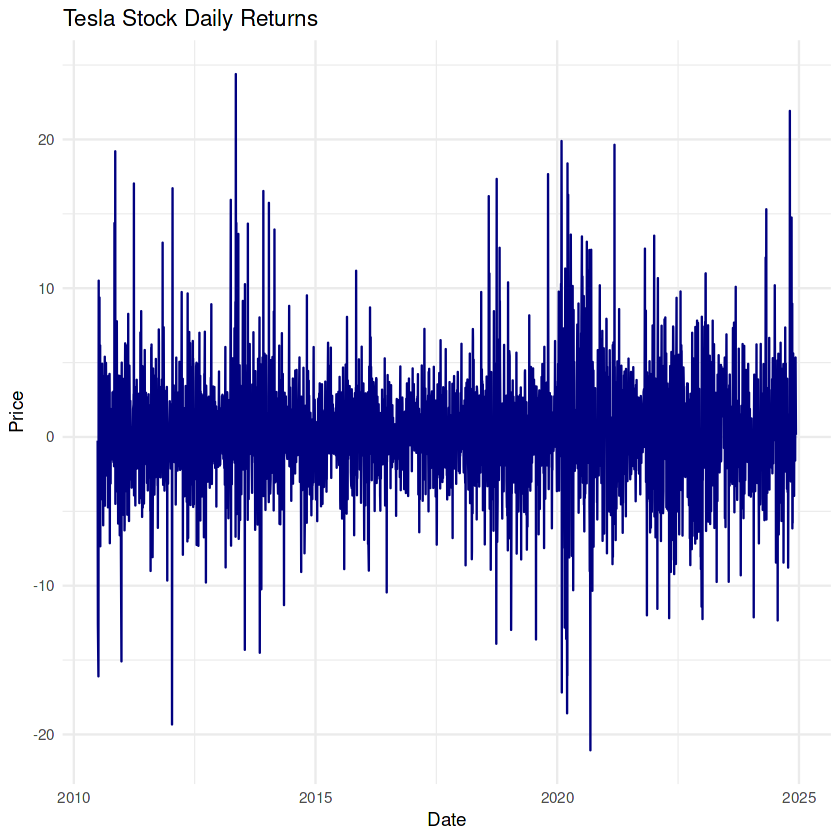

In [4]:
#daily return graph
ggplot(tesla, aes(x = Date))+
geom_line(aes(y = Daily_Return), color = "navy blue")+
xlab("Date")+
ylab("Price")+
ggtitle("Tesla Stock Daily Returns")+
theme_minimal()


## Tesla Daily Return Observations
* the graph shows the daily fluctuating of Tesla Stock at Zero, this shows that throughout the year there has been significant daily price changes.
* this graph shows high volatality. The dense cluster suggests that stock has experienced many periods of high volatality.

In [5]:
install.packages("zoo")
library(zoo)
#calculate moving averages
tesla <- tesla %>%
mutate(SMA_10 = rollmean(Close, 10, fill = NA),
       SMA_30 = rollmean(Close, 30, fill = NA))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




Attaching package: ‘zoo’




The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_line()`).”


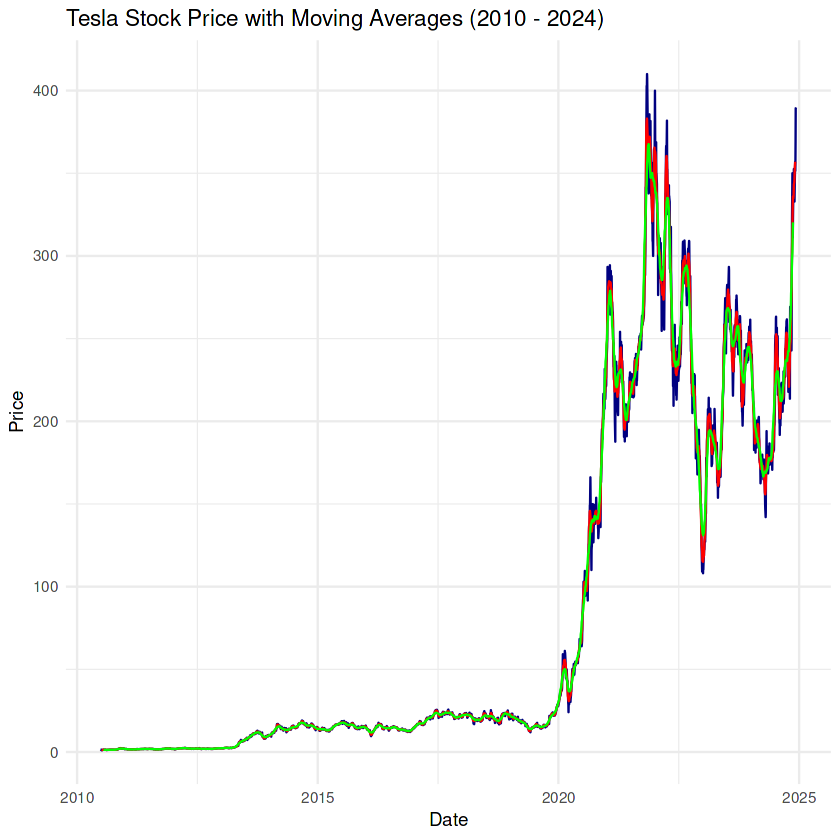

In [6]:
#moving averages graph
ggplot(tesla, aes(x = Date)) +
geom_line(aes(y = Close), color = "navy blue" )+
geom_line(aes(y = SMA_10), color = "red")+
geom_line(aes(y = SMA_30), color = "green")+
xlab("Date")+
ylab("Price")+
ggtitle("Tesla Stock Price with Moving Averages (2010 - 2024)")+
theme_minimal()

##  Tesla's Moving Average Observations
* the overall graph shows that there has been a significant increase in Tesla's stock prices over the years from 2010 to 2024.
* from the year 2010 to 2019, the price was relatively stable.
* from 2020 to 2024, that is where we see a sharp increase in stock price.
* the 2020 to 2024 period continues with fluctautions in their stock price.


#  Key Insights
* Over the years the has been a rapid growth in Tesla's stock prices, which can be a result of product launches, increased market share as well increased investors interest.
* However as much as there has been an increase in stock price, as seen in the daily returns graph. It is seen that on certain days the prices would be on the negetive side of the graph meaning that Tesla would experience significant loses. This highlights the risk-reward aspect of investing in Tesla. This is key in ensuring that investors are familiarised with market conditions and the company's performance.
* Despite the short-term loses, Investors can consider the long term growth potential before making investment decisions.
 